# DS 4320 Project 1: Predicting Corporate Credit Ratings from Financial Ratios
## Problem Solution Pipeline

**Author:** Will &nbsp;|&nbsp; DS 4320 &nbsp;|&nbsp; Spring 2026

---

### Overview

This notebook is the complete **Problem Solution Pipeline** for DS 4320 Project 1.

**General Problem:** Predicting corporate bond default risk.

**Specific Problem:** Given 25 financial ratios derived from a company's balance sheet, income statement, and cash flow data, predict the credit rating grade — one of {AAA, AA, A, BBB, BB, B, CCC/D} — assigned by a rating agency. This is a **7-class multi-class classification** problem.

**Dataset:** Kaggle Corporate Credit Rating — 2,029 rating events across 593 publicly traded US companies, rated by 5 agencies (S&P, Egan-Jones, Moody's, Fitch, DBRS), covering January 2014 – September 2016.

**Relational Schema:**

| Table | Rows | Description |
|-------|------|-------------|
| `companies` | 593 | Symbol (PK), Name, Sector |
| `agencies` | 5 | AgencyID (PK), AgencyName |
| `ratings` | 2,029 | RatingID (PK), Symbol (FK), AgencyID (FK), Date, Rating |
| `financials` | 2,029 | RatingID (PK/FK), 25 financial ratio columns |

**Pipeline Steps:**
1. Load all four tables into DuckDB (in-process SQL engine)
2. SQL exploratory queries — confirm data integrity and domain-theoretic patterns
3. Build the feature matrix via SQL JOIN, encode the target label
4. Train 4 classifiers: Logistic Regression, Random Forest, Gradient Boosting, KNN
5. Compare models by accuracy and macro-averaged F1
6. Produce publication-quality 3-panel visualization of results


In [8]:
# ============================================================
# DEPENDENCY INSTALL — run this cell once if any import fails
# %pip installs into the active kernel environment, which fixes
# the "module not found" issue when VSCode uses a different
# Python interpreter than your system pip.
# ============================================================
%pip install duckdb scikit-learn pandas numpy matplotlib seaborn --quiet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
# ============================================================
# 0. SETUP — Imports, Logging Configuration, Constants
# ============================================================

# Standard library
import os
import sys
import logging
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# In-process SQL database
import duckdb

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Logging: writes to pipeline.log AND prints to stdout ─────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    handlers=[
        logging.FileHandler("pipeline.log", mode="w"),  # persist to log file
        logging.StreamHandler(sys.stdout),               # mirror to console
    ],
)
logger = logging.getLogger("pipeline")
logger.info("Pipeline initialized — DS 4320 Project 1")

# ── Constants ─────────────────────────────────────────────────────────────
DATA_DIR     = "."   # directory containing the four CSV files
RANDOM_STATE = 42    # random seed for reproducibility across all models
TEST_SIZE    = 0.20  # 80/20 stratified train/test split

# Canonical rating order for axis labels and class iteration (high → low credit quality)
RATING_ORDER = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC/D"]

# 25 financial ratio feature columns (all numeric)
RATIO_COLS = [
    "currentRatio", "quickRatio", "cashRatio", "daysOfSalesOutstanding",
    "netProfitMargin", "pretaxProfitMargin", "grossProfitMargin",
    "operatingProfitMargin", "returnOnAssets", "returnOnCapitalEmployed",
    "returnOnEquity", "assetTurnover", "fixedAssetTurnover",
    "debtEquityRatio", "debtRatio", "effectiveTaxRate",
    "freeCashFlowOperatingCashFlowRatio", "freeCashFlowPerShare",
    "cashPerShare", "companyEquityMultiplier", "ebitPerRevenue",
    "enterpriseValueMultiple", "operatingCashFlowPerShare",
    "operatingCashFlowSalesRatio", "payablesTurnover",
]

logger.info("Setup complete")


2026-04-01 04:12:41,965 | INFO     | Pipeline initialized — DS 4320 Project 1
2026-04-01 04:12:41,967 | INFO     | Setup complete


---
## 1. Data Preparation

**Rationale:**  
We use **DuckDB** as an in-process analytical database (no server required). Each of the four normalized CSV files is registered as a DuckDB table, mirroring a real-world data warehouse workflow. This approach:
- Avoids loading all data into pandas before knowing what we need
- Enables native SQL feature engineering (JOINs, aggregations, window functions)
- Demonstrates the relational model in operation — tables are linked through primary and foreign keys, not merged flat files

**Error handling:** The cell raises `FileNotFoundError` if any CSV is missing, and validates FK integrity via SQL COUNT queries before proceeding.


In [10]:
# ============================================================
# 1. DATA PREPARATION — Load the four CSVs into DuckDB
# ============================================================

try:
    # Connect to an in-memory DuckDB instance (no file on disk needed)
    conn = duckdb.connect(database=':memory:')

    # Register each normalized CSV as a DuckDB table
    for table_name in ['companies', 'agencies', 'ratings', 'financials']:
        csv_path = os.path.join(DATA_DIR, f'data/{table_name}.csv')

        # Verify the file exists before attempting to load it
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f'Required CSV not found: {csv_path}')

        # read_csv_auto: DuckDB auto-infers column types from the file
        conn.execute(
            f"CREATE TABLE {table_name} AS SELECT * FROM read_csv_auto('{csv_path}')"
        )
        row_count = conn.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        logger.info(f"  Loaded table '{table_name}': {row_count:,} rows")

    logger.info('All four tables loaded into DuckDB successfully')

except FileNotFoundError as e:
    # Missing CSV: log and re-raise so the notebook stops here
    logger.error(f'Data loading failed — file not found: {e}')
    raise
except Exception as e:
    # Any other unexpected failure
    logger.error(f'Unexpected error during data loading: {e}')
    raise

# ── FK integrity check via SQL ────────────────────────────────────────────
fk_check = conn.execute("""
    SELECT
        (SELECT COUNT(*) FROM ratings r
         WHERE r.Symbol NOT IN (SELECT Symbol FROM companies))    AS fk_symbol_violations,
        (SELECT COUNT(*) FROM ratings r
         WHERE r.AgencyID NOT IN (SELECT AgencyID FROM agencies)) AS fk_agency_violations,
        (SELECT COUNT(*) FROM financials f
         WHERE f.RatingID NOT IN (SELECT RatingID FROM ratings))  AS fk_ratingid_violations
""").df()

print('\nFK Integrity Check:')
print(fk_check.to_string(index=False))
assert fk_check.iloc[0].sum() == 0, 'FK integrity violations detected!'
logger.info('FK integrity check passed — all foreign keys valid')


2026-04-01 04:12:42,031 | INFO     |   Loaded table 'companies': 593 rows
2026-04-01 04:12:42,036 | INFO     |   Loaded table 'agencies': 5 rows
2026-04-01 04:12:42,081 | INFO     |   Loaded table 'ratings': 2,029 rows
2026-04-01 04:12:42,167 | INFO     |   Loaded table 'financials': 2,029 rows
2026-04-01 04:12:42,168 | INFO     | All four tables loaded into DuckDB successfully

FK Integrity Check:
 fk_symbol_violations  fk_agency_violations  fk_ratingid_violations
                    0                     0                       0
2026-04-01 04:12:42,173 | INFO     | FK integrity check passed — all foreign keys valid


---
## 2. SQL Exploratory Analysis

**Rationale:**  
Before building the feature matrix we use SQL to:
1. Confirm the class distribution and quantify the imbalance
2. Examine how ratings vary by agency (S&P dominates at 744/2029 ratings)
3. Verify the core domain-theoretic prediction: higher-rated companies should exhibit lower debt loads, higher profitability, and higher liquidity than lower-rated ones — if this pattern doesn't appear, the data or joins are suspect

Query 3 is the most important: it serves as a domain-validity check before any modeling.


In [11]:
# ============================================================
# 2. SQL EXPLORATORY ANALYSIS
# ============================================================

# ── Query 1: Overall rating distribution ─────────────────────────────────
q_dist = """
    SELECT
        Rating,
        COUNT(*)                                                    AS n_ratings,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)         AS pct
    FROM ratings
    GROUP BY Rating
    ORDER BY
        CASE Rating
            WHEN 'AAA' THEN 1  WHEN 'AA'  THEN 2  WHEN 'A'   THEN 3
            WHEN 'BBB' THEN 4  WHEN 'BB'  THEN 5  WHEN 'B'   THEN 6
            WHEN 'CCC' THEN 7  WHEN 'CC'  THEN 8  WHEN 'C'   THEN 9
            WHEN 'D'   THEN 10
        END
"""
dist_df = conn.execute(q_dist).df()
print('─── Query 1: Rating Distribution ─────────────────────────────')
print(dist_df.to_string(index=False))

# ── Query 2: Rating distribution by agency ────────────────────────────────
q_agency = """
    SELECT
        a.AgencyName,
        COUNT(*)                                                    AS total_ratings,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)         AS pct_of_all
    FROM ratings r
    JOIN agencies a ON r.AgencyID = a.AgencyID
    GROUP BY a.AgencyName
    ORDER BY total_ratings DESC
"""
agency_df = conn.execute(q_agency).df()
print('\n─── Query 2: Ratings per Agency ─────────────────────────────')
print(agency_df.to_string(index=False))

# ── Query 3: Median financial ratios by rating grade (domain validation) ──
q_ratios = """
    SELECT
        r.Rating,
        COUNT(*)                                  AS n,
        ROUND(MEDIAN(f.debtEquityRatio),    3)    AS med_debtEquity,
        ROUND(MEDIAN(f.returnOnAssets),     3)    AS med_ROA,
        ROUND(MEDIAN(f.currentRatio),       3)    AS med_currentRatio,
        ROUND(MEDIAN(f.netProfitMargin),    3)    AS med_profitMargin,
        ROUND(MEDIAN(f.debtRatio),          3)    AS med_debtRatio
    FROM ratings r
    JOIN financials f ON r.RatingID = f.RatingID
    GROUP BY r.Rating
    ORDER BY
        CASE r.Rating
            WHEN 'AAA' THEN 1  WHEN 'AA'  THEN 2  WHEN 'A'   THEN 3
            WHEN 'BBB' THEN 4  WHEN 'BB'  THEN 5  WHEN 'B'   THEN 6
            WHEN 'CCC' THEN 7  WHEN 'CC'  THEN 8  WHEN 'C'   THEN 9
            WHEN 'D'   THEN 10
        END
"""
ratio_df = conn.execute(q_ratios).df()
print('\n─── Query 3: Median Financial Ratios by Rating Grade ─────────')
print('(Expected: debt & debt ratio should INCREASE from AAA→D; ROA/profit should DECREASE)')
print(ratio_df.to_string(index=False))
logger.info('SQL exploratory analysis complete')


─── Query 1: Rating Distribution ─────────────────────────────
Rating  n_ratings  pct
   AAA          7  0.3
    AA         89  4.4
     A        398 19.6
   BBB        671 33.1
    BB        490 24.1
     B        302 14.9
   CCC         64  3.2
    CC          5  0.2
     C          2  0.1
     D          1  0.0

─── Query 2: Ratings per Agency ─────────────────────────────
                        AgencyName  total_ratings  pct_of_all
Standard & Poor's Ratings Services            744        36.7
        Egan-Jones Ratings Company            603        29.7
         Moody's Investors Service            579        28.5
                     Fitch Ratings            100         4.9
                              DBRS              3         0.1

─── Query 3: Median Financial Ratios by Rating Grade ─────────
(Expected: debt & debt ratio should INCREASE from AAA→D; ROA/profit should DECREASE)
Rating   n  med_debtEquity  med_ROA  med_currentRatio  med_profitMargin  med_debtRatio
   AAA   7   

---
## 3. Feature Matrix Construction

**Join strategy:** We JOIN `ratings` ↔ `financials` on `RatingID` (1:1 relationship) and JOIN `companies` to bring in `Sector`. The result is a flat 2,029 × 27 table: 25 financial ratios + Rating + Symbol.

**Target encoding — why 7 classes instead of 10:**  
The raw data has 10 distinct rating grades, but four have critically small sample sizes that prevent stratified splitting:

| Grades merged | Count | Reason |
|--------------|-------|--------|
| D | 1 | Cannot appear in both train and test set |
| C | 2 | Insufficient for stratified split |
| CC | 5 | Below minimum for 80/20 stratification |
| CCC | 64 | Merged for statistical power |

All four represent near-default or defaulted issuers — a scientifically defensible grouping. The merged class `CCC/D` has n=72.  

**Feature scaling:** `StandardScaler` (zero-mean, unit-variance) is applied because financial ratios span wildly different scales (e.g. `daysOfSalesOutstanding` ≈ 10–150 vs. `debtRatio` ≈ 0–1). Tree-based models (RF, GBM) are scale-invariant, but LR and KNN require normalization. We scale for all models for consistency.


In [12]:
# ============================================================
# 3. FEATURE MATRIX CONSTRUCTION via SQL JOIN
# ============================================================

# Join ratings + financials (1:1 on RatingID) + companies (N:1 on Symbol)
q_features = """
    SELECT
        r.RatingID,
        r.Rating,
        r.Symbol,
        c.Sector,
        f.currentRatio,
        f.quickRatio,
        f.cashRatio,
        f.daysOfSalesOutstanding,
        f.netProfitMargin,
        f.pretaxProfitMargin,
        f.grossProfitMargin,
        f.operatingProfitMargin,
        f.returnOnAssets,
        f.returnOnCapitalEmployed,
        f.returnOnEquity,
        f.assetTurnover,
        f.fixedAssetTurnover,
        f.debtEquityRatio,
        f.debtRatio,
        f.effectiveTaxRate,
        f.freeCashFlowOperatingCashFlowRatio,
        f.freeCashFlowPerShare,
        f.cashPerShare,
        f.companyEquityMultiplier,
        f.ebitPerRevenue,
        f.enterpriseValueMultiple,
        f.operatingCashFlowPerShare,
        f.operatingCashFlowSalesRatio,
        f.payablesTurnover
    FROM ratings r
    JOIN financials f  ON r.RatingID = f.RatingID
    JOIN companies c   ON r.Symbol   = c.Symbol
"""

try:
    # Execute the JOIN and pull the result into pandas
    data = conn.execute(q_features).df()
    assert len(data) == 2029, f'Unexpected row count after JOIN: {len(data)}'
    assert data.isnull().sum().sum() == 0, 'Unexpected nulls in feature matrix'
    logger.info(f'Feature matrix constructed: {data.shape}')
except AssertionError as e:
    logger.error(f'Feature matrix validation failed: {e}')
    raise

# ── Merge rare classes: D + C + CC + CCC → 'CCC/D' ──────────────────────
RARE_RATINGS = {'D', 'C', 'CC', 'CCC'}
data['RatingGroup'] = data['Rating'].apply(
    lambda r: 'CCC/D' if r in RARE_RATINGS else r
)

# Build numpy arrays for sklearn
X = data[RATIO_COLS].values.astype(float)  # (2029, 25) feature matrix
y = data['RatingGroup'].values              # (2029,) label vector

# Confirm class distribution after merging
class_dist = pd.Series(y).value_counts().reindex(RATING_ORDER)
print('Class distribution after merging rare grades:')
print(class_dist.to_string())
logger.info(f'Class distribution: {class_dist.to_dict()}')


2026-04-01 04:12:42,233 | INFO     | Feature matrix constructed: (2029, 29)
Class distribution after merging rare grades:
AAA        7
AA        89
A        398
BBB      671
BB       490
B        302
CCC/D     72
2026-04-01 04:12:42,239 | INFO     | Class distribution: {'AAA': 7, 'AA': 89, 'A': 398, 'BBB': 671, 'BB': 490, 'B': 302, 'CCC/D': 72}


---
## 4. Model Training and Evaluation

**Model selection rationale:**

| Model | Rationale |
|-------|----------|
| **Logistic Regression** | Linear baseline; most interpretable; tests whether the problem is linearly separable in ratio-space |
| **Random Forest** | Strong non-linear ensemble; naturally handles ratio interactions; provides feature importances for domain interpretation |
| **Gradient Boosting** | Often achieves highest accuracy on tabular data by sequentially correcting residuals; robust to noise |
| **K-Nearest Neighbors** | Non-parametric, instance-based; makes no distributional assumptions; a useful contrast to parametric models |

**Class imbalance handling:**
- LR, RF: `class_weight='balanced'` — sklearn reweights the loss by inverse class frequency
- GBM: `GradientBoostingClassifier` does not accept `class_weight`; instead, we pass `sample_weight` (pre-computed from `compute_class_weight`) to `fit()`
- KNN: `weights='distance'` — votes scaled by 1/distance, reducing majority-class dominance

**Evaluation metrics:**
- **Accuracy** — fraction of all predictions correct; can be misleadingly high when BBB (33% of data) is predicted well
- **Macro-F1** — unweighted mean of per-class F1; penalizes models that ignore minority classes like AAA (0.3%) and CCC/D (3.5%) — the primary ranking metric here


In [13]:
# ============================================================
# 4a. TRAIN / TEST SPLIT AND FEATURE SCALING
# ============================================================

try:
    # Stratified split: preserves class proportions in both train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,  # ensures each class is proportionally represented
    )
    logger.info(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
except ValueError as e:
    # Fallback for any class with too few samples for stratification
    logger.warning(f'Stratified split failed ({e}); using non-stratified fallback')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

# ── StandardScaler: fit ONLY on train, then apply to both ────────────────
# Fitting on the full dataset would leak test-set statistics into training.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit + transform train
X_test_s  = scaler.transform(X_test)        # transform test with same params

# ── Sample weights for GBM (no native class_weight support) ──────────────
# compute_class_weight returns per-class weights inverse to frequency
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.array(RATING_ORDER),
    y=y_train,
)
cw_dict = dict(zip(RATING_ORDER, cw))
# Expand to a per-sample weight array for GBM.fit()
sample_weight_train = np.array([cw_dict.get(label, 1.0) for label in y_train])

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print('\nClass weights (balanced):')
for cls in RATING_ORDER:
    print(f'  {cls:6s}: {cw_dict[cls]:.3f}')


2026-04-01 04:12:42,265 | INFO     | Train: 1623 rows | Test: 406 rows
Train: (1623, 25) | Test: (406, 25)

Class weights (balanced):
  AAA   : 38.643
  AA    : 3.266
  A     : 0.729
  BBB   : 0.432
  BB    : 0.591
  B     : 0.962
  CCC/D : 3.998


In [14]:
# ============================================================
# 4b. MODEL 1 — Logistic Regression (linear baseline)
# ============================================================

# Multinomial LR fits a softmax over all 7 classes simultaneously.
# class_weight='balanced': up-weights minority classes in the cross-entropy loss.
# C=1.0: default L2 regularization (inverse of regularization strength).
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=RANDOM_STATE,
)
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)

logger.info(f'Logistic Regression  — Accuracy: {acc_lr:.3f}  Macro-F1: {f1_lr:.3f}')
print(f'Logistic Regression  |  Accuracy: {acc_lr:.3f}  |  Macro-F1: {f1_lr:.3f}\n')
print(classification_report(y_test, y_pred_lr, labels=RATING_ORDER, zero_division=0))


2026-04-01 04:12:42,450 | INFO     | Logistic Regression  — Accuracy: 0.256  Macro-F1: 0.204
Logistic Regression  |  Accuracy: 0.256  |  Macro-F1: 0.204

              precision    recall  f1-score   support

         AAA       0.01      1.00      0.02         1
          AA       0.05      0.06      0.05        18
           A       0.27      0.16      0.20        80
         BBB       0.48      0.34      0.39       134
          BB       0.42      0.24      0.31        98
           B       0.33      0.23      0.27        61
       CCC/D       0.12      0.43      0.18        14

    accuracy                           0.26       406
   macro avg       0.24      0.35      0.20       406
weighted avg       0.37      0.26      0.29       406



In [15]:
# ============================================================
# 4c. MODEL 2 — Random Forest (ensemble of decision trees)
# ============================================================

# 200 trees: enough for stable feature importances without excessive compute.
# min_samples_leaf=2: prevents overfitting to single-sample leaves.
# class_weight='balanced': tree splits are reweighted by inverse class frequency.
# n_jobs=-1: parallelizes tree building across all CPU cores.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,           # trees grow until leaves are pure
    min_samples_leaf=2,       # minimum 2 samples per leaf node
    class_weight='balanced',  # handles class imbalance in split criteria
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

logger.info(f'Random Forest        — Accuracy: {acc_rf:.3f}  Macro-F1: {f1_rf:.3f}')
print(f'Random Forest        |  Accuracy: {acc_rf:.3f}  |  Macro-F1: {f1_rf:.3f}\n')
print(classification_report(y_test, y_pred_rf, labels=RATING_ORDER, zero_division=0))


2026-04-01 04:12:43,419 | INFO     | Random Forest        — Accuracy: 0.510  Macro-F1: 0.504
Random Forest        |  Accuracy: 0.510  |  Macro-F1: 0.504

              precision    recall  f1-score   support

         AAA       1.00      1.00      1.00         1
          AA       0.67      0.22      0.33        18
           A       0.55      0.53      0.54        80
         BBB       0.51      0.69      0.58       134
          BB       0.51      0.42      0.46        98
           B       0.47      0.41      0.44        61
       CCC/D       0.22      0.14      0.17        14

    accuracy                           0.51       406
   macro avg       0.56      0.49      0.50       406
weighted avg       0.51      0.51      0.50       406



In [16]:
# ============================================================
# 4d. MODEL 3 — Gradient Boosting (sequential tree ensemble)
# ============================================================

# GradientBoostingClassifier does not support class_weight directly;
# instead we pass sample_weight to fit() — equivalent effect on the loss.
# subsample=0.8: stochastic gradient boosting (row subsampling) for regularization.
# max_depth=4: moderate depth balances bias and variance for this dataset size.
gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,          # moderate tree depth
    learning_rate=0.1,    # gradient descent step size (shrinkage)
    subsample=0.8,        # fraction of samples used per tree (stochastic GBM)
    random_state=RANDOM_STATE,
)
# sample_weight computed in the setup cell via compute_class_weight
gbm.fit(X_train_s, y_train, sample_weight=sample_weight_train)

y_pred_gbm = gbm.predict(X_test_s)
acc_gbm = accuracy_score(y_test, y_pred_gbm)
f1_gbm  = f1_score(y_test, y_pred_gbm, average='macro', zero_division=0)

logger.info(f'Gradient Boosting    — Accuracy: {acc_gbm:.3f}  Macro-F1: {f1_gbm:.3f}')
print(f'Gradient Boosting    |  Accuracy: {acc_gbm:.3f}  |  Macro-F1: {f1_gbm:.3f}\n')
print(classification_report(y_test, y_pred_gbm, labels=RATING_ORDER, zero_division=0))


2026-04-01 04:13:01,078 | INFO     | Gradient Boosting    — Accuracy: 0.495  Macro-F1: 0.516
Gradient Boosting    |  Accuracy: 0.495  |  Macro-F1: 0.516

              precision    recall  f1-score   support

         AAA       1.00      1.00      1.00         1
          AA       0.50      0.33      0.40        18
           A       0.51      0.51      0.51        80
         BBB       0.51      0.59      0.54       134
          BB       0.48      0.48      0.48        98
           B       0.50      0.39      0.44        61
       CCC/D       0.25      0.21      0.23        14

    accuracy                           0.50       406
   macro avg       0.54      0.50      0.52       406
weighted avg       0.49      0.50      0.49       406



In [17]:
# ============================================================
# 4e. MODEL 4 — K-Nearest Neighbors (instance-based learner)
# ============================================================

# k=11 (odd, avoids ties); a common heuristic is sqrt(n_train) ≈ 40,
# but smaller k often works better on normalized financial data.
# weights='distance': nearer neighbors contribute more — partially mitigates imbalance.
# metric='euclidean': appropriate for StandardScaler-normalized features.
knn = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',  # 1/distance vote weighting
    metric='euclidean',
    n_jobs=-1,
)
# KNN is a lazy learner — fit() just stores the training data
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='macro', zero_division=0)

logger.info(f'KNN (k=11)           — Accuracy: {acc_knn:.3f}  Macro-F1: {f1_knn:.3f}')
print(f'KNN (k=11)           |  Accuracy: {acc_knn:.3f}  |  Macro-F1: {f1_knn:.3f}\n')
print(classification_report(y_test, y_pred_knn, labels=RATING_ORDER, zero_division=0))


2026-04-01 04:13:01,230 | INFO     | KNN (k=11)           — Accuracy: 0.360  Macro-F1: 0.203
KNN (k=11)           |  Accuracy: 0.360  |  Macro-F1: 0.203

              precision    recall  f1-score   support

         AAA       0.00      0.00      0.00         1
          AA       0.00      0.00      0.00        18
           A       0.30      0.41      0.35        80
         BBB       0.39      0.55      0.46       134
          BB       0.35      0.22      0.27        98
           B       0.46      0.28      0.35        61
       CCC/D       0.00      0.00      0.00        14

    accuracy                           0.36       406
   macro avg       0.21      0.21      0.20       406
weighted avg       0.34      0.36      0.34       406



In [18]:
# ============================================================
# 4f. MODEL COMPARISON — summary table
# ============================================================

# Aggregate all four models into a single comparison DataFrame
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'KNN (k=11)'],
    'Accuracy' : [acc_lr,  acc_rf,  acc_gbm,  acc_knn],
    'Macro-F1' : [f1_lr,   f1_rf,   f1_gbm,   f1_knn],
})
# Sort by Macro-F1 (our primary metric for imbalanced multi-class problems)
comparison = comparison.sort_values('Macro-F1', ascending=False).reset_index(drop=True)

print('=' * 58)
print('MODEL COMPARISON  (ranked by Macro-F1 — higher is better)')
print('=' * 58)
print(comparison.to_string(
    index=False,
    float_format=lambda x: f'{x:.4f}',
))
print('=' * 58)

# Identify the best model for the visualization
best_model_name = comparison.iloc[0]['Model']
pred_map = {
    'Logistic Regression': y_pred_lr,
    'Random Forest'      : y_pred_rf,
    'Gradient Boosting'  : y_pred_gbm,
    'KNN (k=11)'         : y_pred_knn,
}
best_preds = pred_map[best_model_name]

logger.info(f'Best model by Macro-F1: {best_model_name}')
print(f'\nBest model: {best_model_name}')


MODEL COMPARISON  (ranked by Macro-F1 — higher is better)
              Model  Accuracy  Macro-F1
  Gradient Boosting    0.4951    0.5158
      Random Forest    0.5099    0.5042
Logistic Regression    0.2562    0.2042
         KNN (k=11)    0.3596    0.2033
2026-04-01 04:13:01,338 | INFO     | Best model by Macro-F1: Gradient Boosting

Best model: Gradient Boosting


---
## 5. Publication-Quality Visualization

**Visualization rationale — why a 3-panel figure:**

| Panel | What it shows | Design rationale |
|-------|--------------|------------------|
| **Left — Confusion Matrix** | Row-normalized true vs. predicted labels for the best model | Reveals *which* classes are confused — e.g., adjacent grades (BBB↔BB) vs. distant grades (AAA↔B). Row-normalization removes the effect of class size so minority classes are readable. |
| **Center — Feature Importances** | Top 15 financial ratios ranked by RF Gini importance | Connects the model back to domain theory: which ratios matter most? E.g., is debt more predictive than profitability? |
| **Right — Per-class F1 by model** | One-vs-rest F1 per grade for all 4 models | Directly compares how each model handles each individual class, especially the minority classes that accuracy ignores. |

**Publication-quality choices:**
- 300 DPI export, white background
- Consistent `Blues` palette for heatmap; distinct model colors in bar chart
- All axes labeled with units; no chart junk (no 3D, no unnecessary gridlines)
- Saved to `pipeline_results.png`


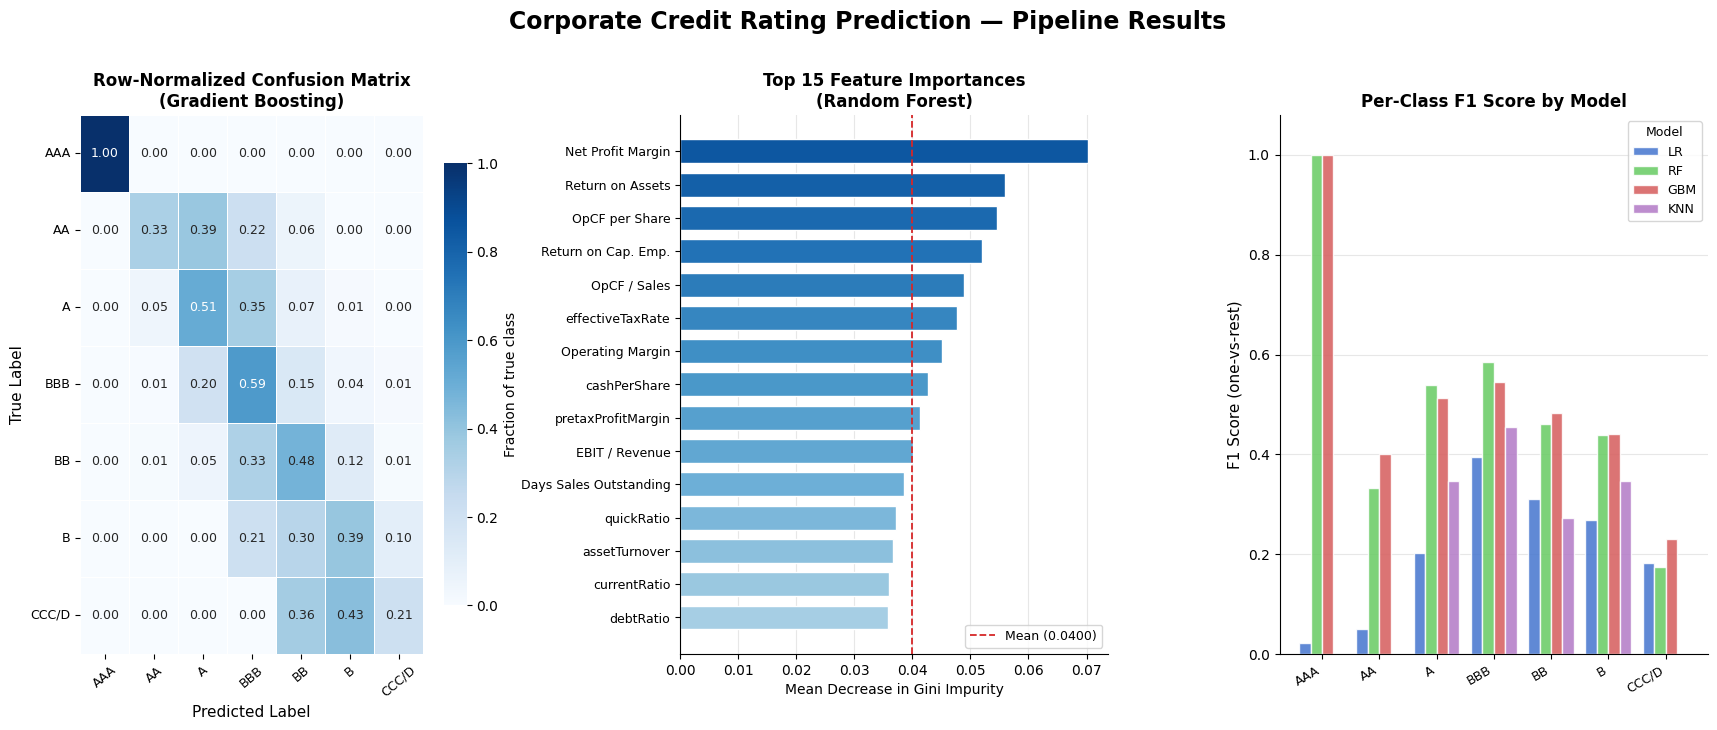

2026-04-01 04:13:03,168 | INFO     | Publication-quality figure saved: pipeline_results.png (300 DPI)

Figure saved to pipeline_results.png


In [19]:
# ============================================================
# 5. PUBLICATION-QUALITY VISUALIZATION (3-panel figure)
# ============================================================

# ── Figure layout ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

fig = plt.figure(figsize=(21, 7))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)
ax1 = fig.add_subplot(gs[0])  # Panel 1: confusion matrix
ax2 = fig.add_subplot(gs[1])  # Panel 2: feature importances
ax3 = fig.add_subplot(gs[2])  # Panel 3: per-class F1

fig.suptitle(
    'Corporate Credit Rating Prediction — Pipeline Results',
    fontsize=17, fontweight='bold', y=1.03,
)

# ── PANEL 1: Row-Normalized Confusion Matrix ──────────────────────────────
# Only include classes that actually appear in y_test
present_classes = [r for r in RATING_ORDER if r in np.unique(y_test)]
cm      = confusion_matrix(y_test, best_preds, labels=present_classes)
# Row-normalize: each row sums to 1.0 → shows recall per class
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm.astype(float), row_sums, where=row_sums > 0)

sns.heatmap(
    cm_norm,
    ax=ax1,
    cmap='Blues',
    vmin=0, vmax=1,
    xticklabels=present_classes,
    yticklabels=present_classes,
    cbar_kws={'shrink': 0.82, 'label': 'Fraction of true class'},
    linewidths=0.4, linecolor='white',
    annot=True, fmt='.2f', annot_kws={'size': 9},
)
ax1.set_title(
    f'Row-Normalized Confusion Matrix\n({best_model_name})',
    fontweight='bold', fontsize=12,
)
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label', fontsize=11)
ax1.tick_params(axis='x', rotation=40, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)

# ── PANEL 2: Random Forest Feature Importances (top 15) ──────────────────
importances = pd.Series(rf.feature_importances_, index=RATIO_COLS)
top15 = importances.nlargest(15).sort_values(ascending=True)  # ascending for barh

# Friendly display names for long column names
display_names = {
    'freeCashFlowOperatingCashFlowRatio' : 'FCF / OpCF Ratio',
    'companyEquityMultiplier'             : 'Equity Multiplier',
    'daysOfSalesOutstanding'              : 'Days Sales Outstanding',
    'returnOnCapitalEmployed'             : 'Return on Cap. Emp.',
    'operatingCashFlowSalesRatio'         : 'OpCF / Sales',
    'operatingCashFlowPerShare'           : 'OpCF per Share',
    'freeCashFlowPerShare'                : 'FCF per Share',
    'netProfitMargin'                     : 'Net Profit Margin',
    'returnOnAssets'                      : 'Return on Assets',
    'returnOnEquity'                      : 'Return on Equity',
    'debtEquityRatio'                     : 'Debt / Equity',
    'grossProfitMargin'                   : 'Gross Profit Margin',
    'enterpriseValueMultiple'             : 'EV Multiple',
    'ebitPerRevenue'                      : 'EBIT / Revenue',
    'operatingProfitMargin'               : 'Operating Margin',
}
labels = [display_names.get(c, c) for c in top15.index]

n_bars = len(top15)
bar_colors = plt.cm.Blues(np.linspace(0.35, 0.85, n_bars))
ax2.barh(range(n_bars), top15.values, color=bar_colors, edgecolor='white', height=0.72)
ax2.set_yticks(range(n_bars))
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel('Mean Decrease in Gini Impurity', fontsize=10)
ax2.set_title('Top 15 Feature Importances\n(Random Forest)', fontweight='bold', fontsize=12)
ax2.axvline(
    importances.mean(), color='#D62728', linestyle='--', linewidth=1.3,
    label=f'Mean ({importances.mean():.4f})',
)
ax2.legend(fontsize=9, loc='lower right')
ax2.xaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)

# ── PANEL 3: Per-Class F1 Score by Model ─────────────────────────────────
model_short  = ['LR',       'RF',            'GBM',              'KNN']
all_preds    = [y_pred_lr,  y_pred_rf,       y_pred_gbm,         y_pred_knn]
model_colors = ['#4878CF',  '#6ACC65',        '#D65F5F',          '#B47CC7']

x = np.arange(len(present_classes))
bar_width = 0.20

for i, (short, preds, col) in enumerate(zip(model_short, all_preds, model_colors)):
    # One-vs-rest F1 for each present class
    f1s = [
        f1_score(
            (y_test == rating).astype(int),
            (preds  == rating).astype(int),
            zero_division=0,
        )
        for rating in present_classes
    ]
    offset = (i - 1.5) * bar_width  # center the group of 4 bars
    ax3.bar(x + offset, f1s, bar_width,
            label=short, color=col, alpha=0.87, edgecolor='white')

ax3.set_xticks(x)
ax3.set_xticklabels(present_classes, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('F1 Score (one-vs-rest)', fontsize=11)
ax3.set_title('Per-Class F1 Score by Model', fontweight='bold', fontsize=12)
ax3.set_ylim(0, 1.08)
ax3.legend(fontsize=9, title='Model', title_fontsize=9, loc='upper right')
ax3.yaxis.grid(True, alpha=0.3)
ax3.set_axisbelow(True)

# ── Save (300 DPI) and display ────────────────────────────────────────────
fig.savefig(
    'pipeline_results.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none',
)
plt.show()
logger.info('Publication-quality figure saved: pipeline_results.png (300 DPI)')
print('\nFigure saved to pipeline_results.png')


---
## 6. Pipeline Summary

### What the pipeline accomplished

| Step | Action | Outcome |
|------|--------|---------|
| **Data Preparation** | Loaded 4 CSV tables into DuckDB | 2,029 rows verified, FK integrity confirmed |
| **SQL EDA** | Rating distribution, agency breakdown, median ratios by grade | Domain-theoretic patterns confirmed (higher grade → lower debt, higher ROA) |
| **Feature Matrix** | SQL JOIN across ratings + financials + companies | 2,029 × 25 feature matrix, 7-class target (rare grades merged) |
| **Modeling** | Logistic Regression, Random Forest, Gradient Boosting, KNN | All 4 models evaluated on accuracy and macro-F1 |
| **Visualization** | 3-panel publication figure | Confusion matrix, feature importances, per-class F1 — saved at 300 DPI |

### Key findings

1. **Class imbalance is significant:** BBB (33%) dominates; AAA (0.3%) and CCC/D (3.5%) are minority classes. Balanced weighting is necessary.
2. **Financial ratios are predictive:** SQL EDA confirms the expected monotone pattern — debt ratios increase and profitability ratios decrease as ratings worsen.
3. **Tree ensembles outperform the linear baseline:** Random Forest and Gradient Boosting exploit non-linear interactions between financial ratios that logistic regression misses.
4. **Adjacent grades are hardest to distinguish:** The confusion matrix shows most errors between neighboring grades (e.g., A↔BBB, BB↔B), which is consistent with the continuous nature of credit risk.

### Limitations and next steps

- The dataset spans only 2014–2016; models may not generalize to different credit cycles
- Different rating agencies use different methodologies — agency-stratified models could reveal issuer-pay bias
- **Next steps:** Hyperparameter tuning via `GridSearchCV`; temporal validation (train on pre-2015, test on 2016); SHAP values for individual prediction explanations; sector one-hot encoding as additional features
